https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-observing-strategies/nirspec-msata-reference-star-selection-recommended-strategies

need ~25 reference objects over the entire MSA, of which ~25% will likely be usable, yielding the ~6 we need.

In [1]:
#%matplotlib inline
%matplotlib notebook
import matplotlib.pyplot as plt

In [2]:
import os
import numpy as np
from glob import glob
from os.path import join
from os.path import expanduser
home = expanduser("~")

#from astropy.io import ascii
import astropy
from astropy.table import Table, vstack
import astropy.units as u

In [3]:
from PIL import Image, ImageEnhance
import PIL
PIL.Image.MAX_IMAGE_PIXELS = 933120000  # avoid decompression bomb error when loading large images

In [4]:
def roundint(x):
    return int(np.round(x))

def between(lo, x, hi):
    return (lo < x) * (x < hi)

# not detected: mag =  99; magerr = 1-sigma upper limit assuming zero flux
# not observed: mag = -99; magerr = 0
def fluxes2mags(flux, fluxerr):
    nondet = flux < 0  # Non-detection if flux is negative
    unobs = (fluxerr <= 0) + (fluxerr == np.inf)  # Unobserved if flux uncertainty is negative or infinity

    mag = flux.to(u.ABmag)
    magupperlimit = fluxerr.to(u.ABmag) # 1-sigma upper limit if flux=0

    mag = np.where(nondet, 99 * u.ABmag, mag)
    mag = np.where(unobs, -99 * u.ABmag, mag)

    magerr = 2.5 * np.log10(1 + fluxerr/flux) 
    magerr = magerr.value * u.ABmag

    magerr = np.where(nondet, magupperlimit, magerr)
    magerr = np.where(unobs, 0 * u.ABmag, magerr)
    
    return mag, magerr

def extract_id(cat, id, idlabel='id'):
    # Note input id must be same format as cat[idlabel] (int or string)
    # to create an array with mostly False entries and True for id
    # cat['id'] dtype='int64'
    # cat['id'] == 3: [False, False, True, False...]
    # cat['id'] == '3': False
    #
    # obj:          astropy.table.table.Table
    # obj[0]:       astropy.table.row.Row
    # obj['id']:    astropy.table.column.Column
    # obj[0]['id']: numpy.int64
    duck_duck_goose = cat[idlabel] == int(id)
    if len(duck_duck_goose):
        obj = cat[duck_duck_goose]
    return obj[0]

In [5]:
field = 'whl0137'
#indir = '../eazy_v4'
#infile = field + '_phot-eazy.ecsv'

indir = '../catalogs/HST'
infile = field + '_f814w_detections.ecsv'
infile = os.path.join(indir, infile)

catalog = astropy.io.ascii.read(infile)
catalog[:2]

id,x,y,ra,dec,area,a,b,fwhm,ellipticity,orientation,gini,kron_radius,local_background,segment_flux,segment_fluxerr,kron_flux,kron_fluxerr,segment_mag,segment_magerr,kron_mag,kron_magerr
,,,deg,deg,pix2,pix,pix,pix,,deg,,pix,,nJy,nJy,nJy,nJy,mag(AB),mag(AB),mag(AB),mag(AB)
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64,float64,float64,float64,float64
1,nan,nan,nan,nan,262275.0,nan,nan,nan,nan,nan,0.9855737121070509,nan,3.479845218736924e-13,0.0007942034490130466,inf,nan,nan,-99.0,0.0,nan,nan
2,nan,nan,nan,nan,1300.0,nan,nan,nan,nan,nan,0.5162607857431682,nan,-2.728077031649994e-39,5.673791807272399e-34,inf,nan,nan,-99.0,0.0,nan,nan


In [6]:
len(catalog)

10720

In [7]:
nothing = np.isnan(catalog['x'])
catalog = catalog[np.logical_not(nothing)]

In [8]:
len(catalog)

3794

In [9]:
catalog[:2]

id,x,y,ra,dec,area,a,b,fwhm,ellipticity,orientation,gini,kron_radius,local_background,segment_flux,segment_fluxerr,kron_flux,kron_fluxerr,segment_mag,segment_magerr,kron_mag,kron_magerr
,,,deg,deg,pix2,pix,pix,pix,,deg,,pix,,nJy,nJy,nJy,nJy,mag(AB),mag(AB),mag(AB),mag(AB)
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64,float64,float64,float64,float64
142,3999.487873403575,172.73635174029855,24.35018054565958,-8.498886225669185,8.0,0.8598072910429992,0.5943190503486934,1.7404045556383156,0.3087764473039677,-68.28400254183977,0.6495543658617534,1.4,0.0019167234416265643,15.542422418485225,inf,12.687718073185552,inf,-99.0,0.0,-99.0,0.0
143,4008.4622283268177,172.89480991273098,24.350079723499764,-8.498884463771196,8.0,0.8148596214291963,0.5613038412486918,1.6475817846605876,0.31116498291544825,-24.540752545012804,0.7086602472429038,1.4,0.0007477722002279836,15.01603365888896,inf,12.714294136998992,inf,-99.0,0.0,-99.0,0.0


In [10]:
catalog['fwhm'] = catalog['fwhm'] * 0.04

In [11]:
import astropy.units as u
from astropy.io import ascii
from astropy.io import fits
import astropy.wcs as wcs
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord

# Find stars

In [12]:
mags = catalog['segment_mag'].value
mycat = catalog[between(0, mags, 90)]
mags = mycat['segment_mag'].value
Kmags = mags - 3  # see reference star color estimates.ipynb

In [13]:
len(mycat)

3590

<IPython.core.display.Javascript object>


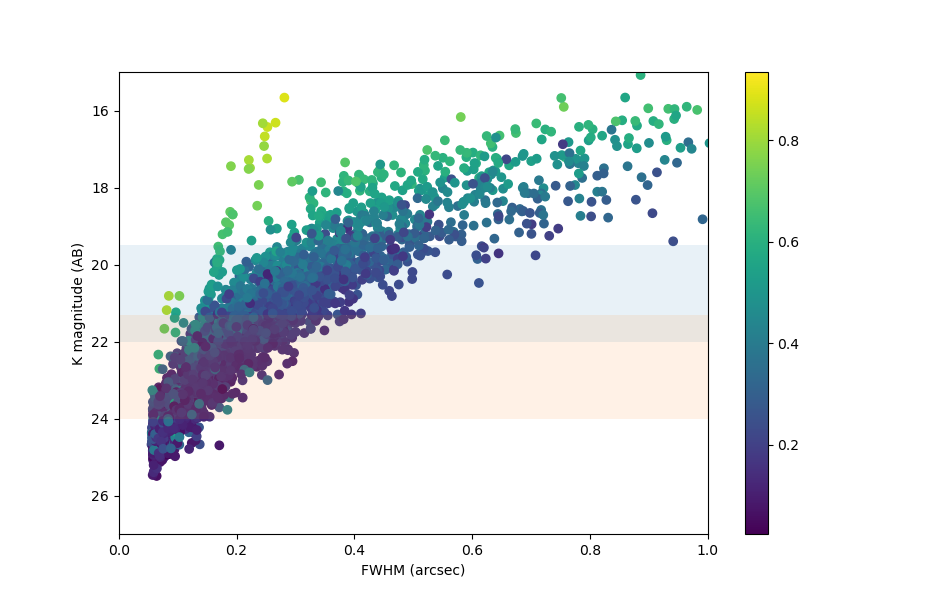

Text(0, 0.5, 'K magnitude (AB)')

In [14]:
fig = plt.figure(figsize=(9.5,6))
#plt.plot(mycat['fwhm'], mycat['f110w_mag'], 'o')
#plt.scatter(mycat['fwhm'], mycat['f110w_mag'], c=mycat['stel'])
#c = np.log10(mycat['peak'] / mycat['flux'])
c = mycat['gini']
#plt.scatter(0.02*mycat['flux_radius'], mycat['f115w_mag'], c=c)
plt.scatter(mycat['fwhm'], Kmags, c=c)
plt.fill_between([0, 1], 19.5, 22, alpha=0.1)
plt.fill_between([0, 1], 21.3, 24, alpha=0.1)
plt.colorbar()
#plt.colorbar(label='Stellarity')
plt.ylim(plt.ylim()[::-1])
plt.xlim(0,1)
#plt.xlim(0,0.5)
plt.ylim(30,18)
plt.ylim(27,15)
plt.xlabel('FWHM (arcsec)')
#plt.xlabel('Flux Radius (arcsec)')
plt.ylabel('K magnitude (AB)')

In [15]:
good_mag = between(21.3, mags, 24)
compact = mycat['fwhm'].value < 0.2

In [16]:
good = good_mag * compact

In [17]:
len(mycat[good]), len(mycat)

(49, 3590)

In [18]:
good_cat = mycat[good]

In [19]:
#infile = '/Users/dcoe/RELICS/data/whl0137-08/epoch4/color/whl0137-08_new_bright.png' # HST
#infile = '/Users/dcoe/RELICS/data/whl0137-08/JWST/color/whl0137_v4_bright.png'
infile = '/Users/dcoe/RELICS/data/whl0137-08/JWST/color/whl0137_hst3.png'
im = Image.open(infile)
imrgb = np.asarray(im)
imrgb = imrgb[::-1]

In [20]:
d_bright = 3.2 * u.arcsec
#within_box = distances < d_bright
#cat_coordinates[within_box]

In [21]:
pixel_scale = 0.02 * u.arcsec
d = d_bright / pixel_scale
d /= 2  # 3.2" box
d = roundint(d)
d

80

In [22]:
good_cat.sort('fwhm')

<IPython.core.display.Javascript object>


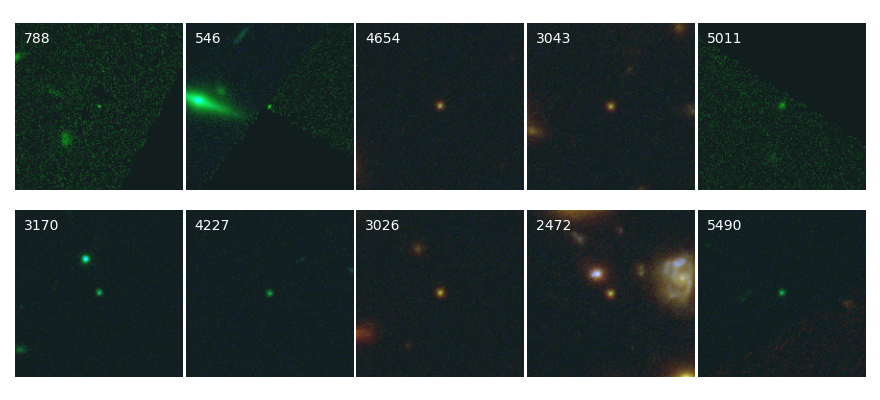

In [24]:
n = 10
ncolumns = 5
nrows = np.ceil(n / ncolumns).astype(int)

fig, ax = plt.subplots(nrows, ncolumns, figsize=(8.8,4))
ax = ax.flatten()

for i in range(ncolumns*nrows):
    ax[i].axis('off')
    
for i in range(n):
    x = roundint(good_cat['x'][i])
    y = roundint(good_cat['y'][i])
    extent = x-d-0.5, x+d+0.5, y-d-0.5, y+d+0.5
    ax[i].imshow(imrgb[y-d:y+d+1,x-d:x+d+1], origin='lower', extent=extent)
    ax[i].text(x-0.9*d,y+0.9*d, good_cat['id'][i], va='top', color='white')
    
plt.tight_layout()
plt.subplots_adjust(hspace=0.02, wspace=0.02)

<IPython.core.display.Javascript object>


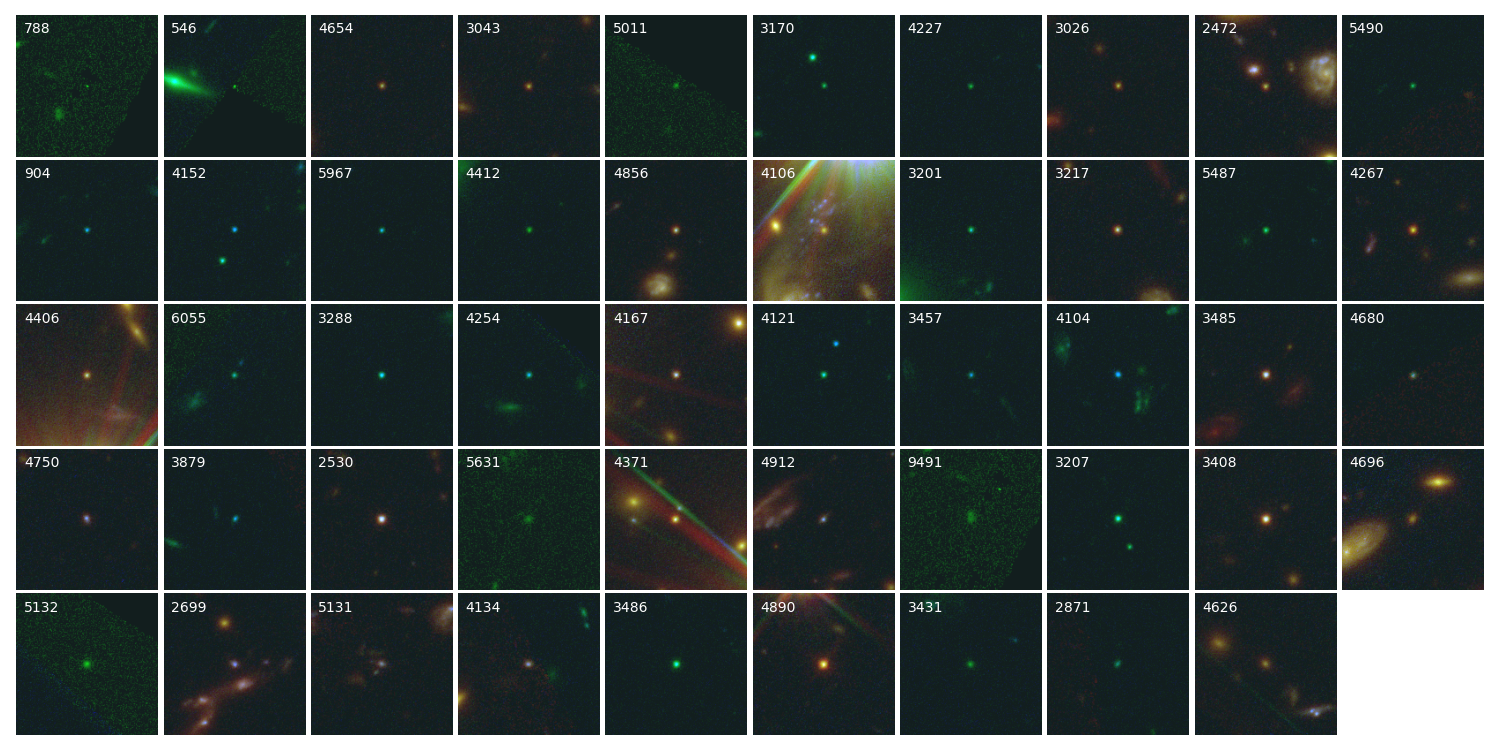

In [31]:
n = len(good_cat)
ncolumns = 10
nrows = np.ceil(n / ncolumns).astype(int)

fig, ax = plt.subplots(nrows, ncolumns, figsize=(15,7.5))
ax = ax.flatten()

for i in range(ncolumns*nrows):
    ax[i].axis('off')
    
for i in range(n):
    x = roundint(good_cat['x'][i])
    y = roundint(good_cat['y'][i])
    extent = x-d-0.5, x+d+0.5, y-d-0.5, y+d+0.5
    ax[i].imshow(imrgb[y-d:y+d+1,x-d:x+d+1], origin='lower', extent=extent)
    ax[i].text(x-0.9*d,y+0.9*d, good_cat['id'][i], va='top', color='white')
    
plt.tight_layout()
plt.subplots_adjust(hspace=0.02, wspace=0.02)

In [32]:
plt.savefig('whl0137_reference_object_candidates_hst.png')

In [ ]:
n = len(good_cat)
ncolumns = 5
nrows = np.ceil(n / ncolumns).astype(int)

fig, ax = plt.subplots(nrows, ncolumns, figsize=(8.8,15))
ax = ax.flatten()

for i in range(ncolumns*nrows):
    ax[i].axis('off')
    
for i in range(n):
    x = roundint(good_cat['x'][i])
    y = roundint(good_cat['y'][i])
    extent = x-d-0.5, x+d+0.5, y-d-0.5, y+d+0.5
    ax[i].imshow(imrgb[y-d:y+d+1,x-d:x+d+1], origin='lower', extent=extent)
    ax[i].text(x-0.9*d,y+0.9*d, good_cat['id'][i], va='top', color='white')
    
plt.tight_layout()
plt.subplots_adjust(hspace=0.02, wspace=0.02)

In [25]:
#good_cat_coordinates = SkyCoord(ra=good_cat['ra']*u.degree, dec=good_cat['dec']*u.degree)
good_cat_coordinates = SkyCoord(ra=good_cat['ra'], dec=good_cat['dec'])

In [26]:
d_bright = 3.2 * u.arcsec  # avoid brighter comapnions within 3.2"
d_faint  = 0.3 * u.arcsec  # avoid fainter  companions within 0.3"

In [27]:
brightest_in_big_box = np.ones(n)
alone_in_small_box   = np.ones(n)
mag = good_cat['segment_mag'].value

for i in range(len(good_cat)):
    #obj_coordinates = SkyCoord(ra=good_cat['ra'][i]*u.degree, dec=good_cat['dec'][i]*u.degree)
    obj_coordinates = SkyCoord(ra=good_cat['ra'][i], dec=good_cat['dec'][i])
    distances = obj_coordinates.separation(good_cat_coordinates)
    
    within_box = distances < d_bright
    within_box = within_box * (distances > 0)  # exclude self (distance = 0)
    idxcatalog = np.where(within_box)[0]
    if np.any(within_box):
        brightest_in_big_box[i] = mag[i] < np.min(mag[idxcatalog])
    
    within_small_box = distances < d_faint
    within_small_box = within_small_box * (distances > 0)  # exclude self (distance = 0)    
    if np.any(within_small_box):
        alone_in_small_box[i] = False
        
    #print(i, '%.2f' % mag[i], brightest_in_big_box[i], alone_in_small_box[i])

IndexError: index 11 is out of bounds for axis 0 with size 10

In [ ]:
all_good = brightest_in_big_box * alone_in_small_box

In [ ]:
np.sum(brightest_in_big_box), np.sum(alone_in_small_box), np.sum(all_good), len(all_good)

In [ ]:
good_star_cat = good_cat[all_good.astype(bool)]
len(good_star_cat)

In [ ]:
#good_ids = 4227, 5490, 904, 5967, 3217, 5487, 3288, 3485, 4680, 4750, 3879, 2530, 3408, 3486

In [33]:
good_ids = 4654, 3043, 5011, 4227, 3026, 5490, 904, 5967, 4412, 3201, 3217, 5487, 4267, 6055, 3288, 4254, 4167, 3457, 4104, 3485, 4680, 4750, 3879, 2530, 5631, 3207, 3408, 5132, 4134, 3486, 3431, 2871

In [34]:
ii = [np.argmin(np.abs(id - good_cat['id'])) for id in good_ids]
ii

[2,
 3,
 4,
 6,
 7,
 9,
 10,
 12,
 13,
 16,
 17,
 18,
 19,
 21,
 22,
 23,
 24,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 37,
 38,
 40,
 43,
 44,
 46,
 47]

In [35]:
good_star_cat = good_cat[ii]

In [ ]:
#good_star_cat = catalog[np.array(good_ids) - 1]

In [ ]:
#good_star_cat

<IPython.core.display.Javascript object>


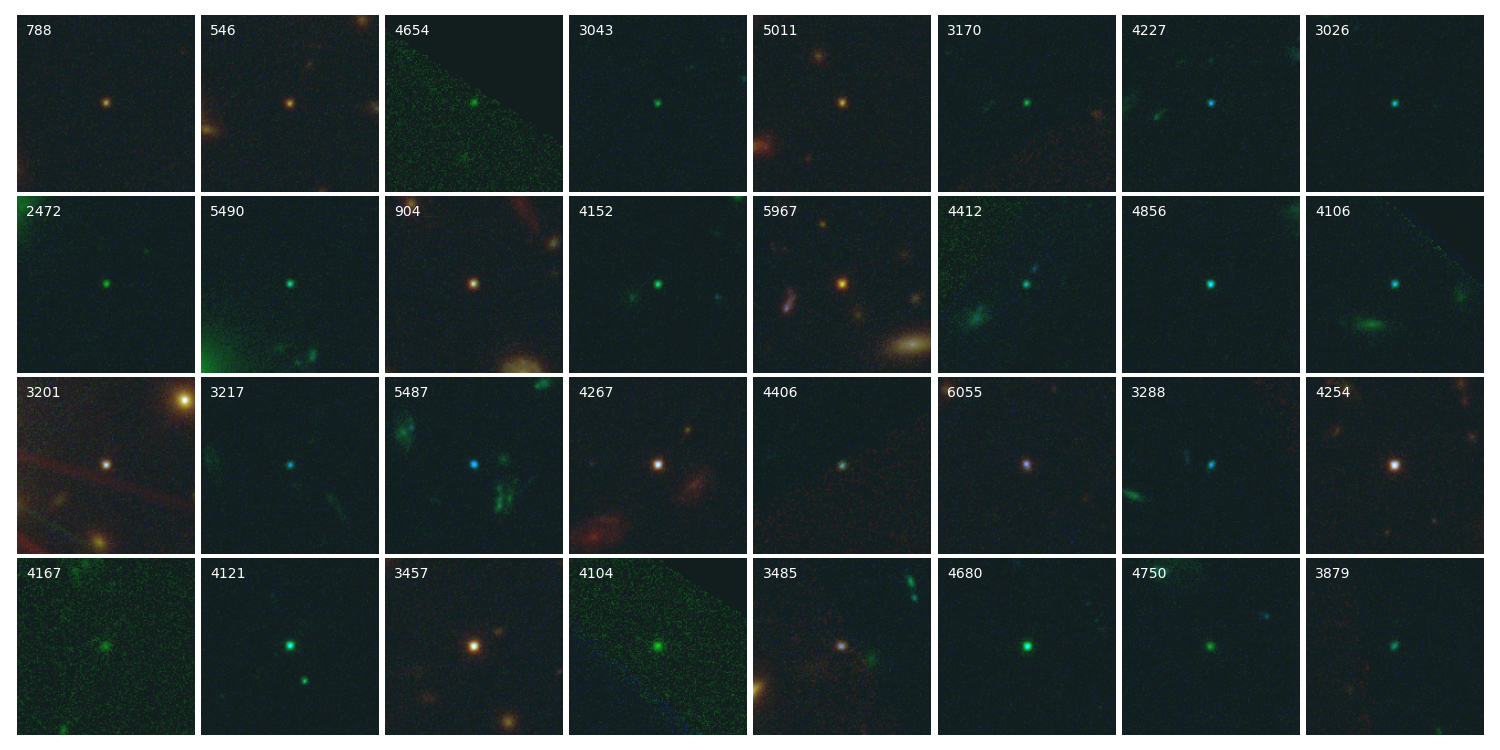

In [40]:
n = len(good_star_cat)
ncolumns = 8
nrows = np.ceil(n / ncolumns).astype(int)

fig, ax = plt.subplots(nrows, ncolumns, figsize=(15,7.5))
ax = ax.flatten()

for i in range(ncolumns*nrows):
    ax[i].axis('off')
    
for i in range(n):
    x = roundint(good_star_cat['x'][i])
    y = roundint(good_star_cat['y'][i])
    extent = x-d-0.5, x+d+0.5, y-d-0.5, y+d+0.5
    ax[i].imshow(imrgb[y-d:y+d+1,x-d:x+d+1], origin='lower', extent=extent)
    ax[i].text(x-0.9*d,y+0.9*d, good_cat['id'][i], va='top', color='white')
    
plt.tight_layout()
plt.subplots_adjust(hspace=0.02, wspace=0.02)

In [41]:
len(good_star_cat)

32

In [42]:
plt.savefig('whl0137_reference_objects_hst.png')